See  http://lpsa.swarthmore.edu/MtrxVibe/Anims/VibrationAnimations.html

In [15]:
#!/usr/bin/env python3
from numpy import array, sqrt, eye
from numpy.linalg import eig



## Part 1: Model the 2-mass system using code on Canvas

In [16]:
from numpy import linspace,array,arange, log,exp,sin,cos,sqrt, pi, zeros, ones
import numpy as np
from numpy.linalg import eig
from matplotlib.pyplot import plot,xlabel,ylabel,legend,show, figure, subplot, title, tight_layout, stem

#  set the time array
T = 10
dt = 0.01

# 1) Fill in t array using arange
t=arange(0,T,dt)

# 2) Create the Matrix M and find the eigenvalues and eigenvectors
M = array([[-2, 1], [1, -2]])

# 3) use eig(M) to store eigen values in array w and eigen vectors in matrix v

w, v = eig(M)

print("Eigenvalues:", w)
print("Eigenvectors:\n", v)



Eigenvalues: [-1. -3.]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


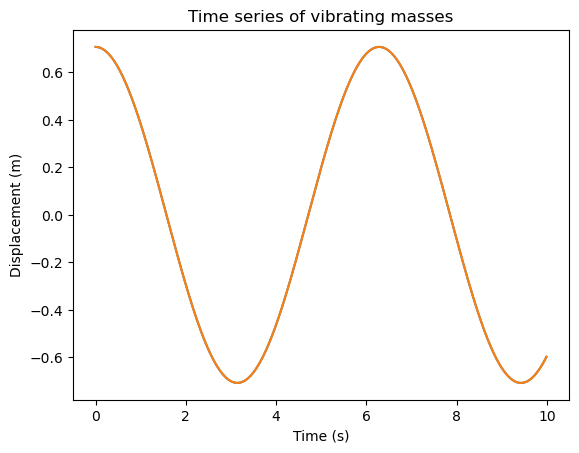

In [17]:

# 4) Create the time series of the motions of the two masses as cosines 
#     for the first eigenvalue/eigenvector. Choosing cosines implies the i.c. is zero velocity.
#  What is omega for the selected mode?
#  What are v1 and v2?

imode = 0

omega = sqrt(-w[imode])
v1 = v[0,imode]
v2 = v[1,imode]

x1 = v1*cos(omega*t)
x2 = v2*cos(omega*t)

plot(t,x1, t,x2)
xlabel('Time (s)')
ylabel('Displacement (m)')
title('Time series of vibrating masses')
show()


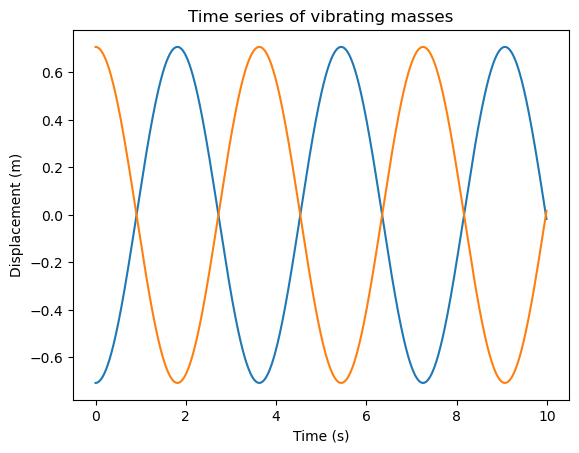

In [18]:

# Repeat for the second mode

imode = 1

omega = sqrt(-w[imode])
v1 = v[0,imode]
v2 = v[1,imode]

x1 = v1*cos(omega*t)
x2 = v2*cos(omega*t)

plot(t,x1, t,x2)
xlabel('Time (s)')
ylabel('Displacement (m)')
title('Time series of vibrating masses')
show()


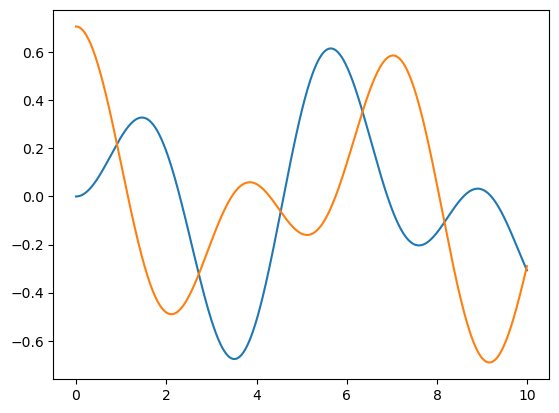

In [19]:

#5 Now superpose a mix of both eigen values with an amplitude of 0.5 each. Plot the motion of the two masses. 
# The amplitude is determined by the initial displacements of the masses.
#   What would the initial conditions be to get 0.5 amplitude assumed?

omega = sqrt(-w)

x1 = 0.5*v[0,0]*cos(omega[0]*t) + 0.5*v[0,1]*cos(omega[1]*t)
x2 = 0.5*v[1,0]*cos(omega[0]*t) + 0.5*v[1,1]*cos(omega[1]*t)    
plot(t,x1, t,x2)
show()


Note that selecting 0.5 for the amplitude of each mode imposes an initial condition. If we want a specific initial condition, we need to solve for these values

In [20]:
print("initial conditions for 0.5 amplitude of each mode: \n  x1(0) = ", x1[0], " x2(0) = ", x2[0])

initial conditions for 0.5 amplitude of each mode: 
  x1(0) =  0.0  x2(0) =  0.7071067811865475


## Part 2: 5 and more masses

Create the Stiffness Matrix and get its eigenvalue eigenvectors

In [21]:

# Create a matrix for the vibrating system. 

# For nx masses connected at both ends, we have:

nx= 5# Number of masses in the system. 
A = -2*np.eye(nx) + np.eye(nx, k=1) + np.eye(nx, k=-1)

# If the masses are not connected at one end, make the upper left corner of the matrix a -1 instead of -2.


d, v =eig(A)          #Find Eigenvalues and vectors.
omega= sqrt(-d)  #Get frequencies from eigenvalues -- omega is a vector containing the nx ANGULAR frequencies


Print out the results

In [28]:

# Print results for the system

print("A=\n",A)
print("d=",d)

print("omega=",omega)

# What are normal (not angular) the frequencies of the system?
frequencies = omega/(2*pi)
print("Normal frequencies:", frequencies)

# Print the eigenvectors as well
for i in range(nx):
    print("Mode ", i, " eigenvector: ", [f"{val:1.3f}" for val in v[:,i]])

A=
 -0.5000000000000002
d= [-3.73205081 -3.         -2.         -0.26794919 -1.        ]
omega= [1.93185165 1.73205081 1.41421356 0.51763809 1.        ]
Normal frequencies: [0.30746374 0.27566445 0.22507908 0.08238466 0.15915494]
Mode  0  eigenvector:  ['-0.289', '0.500', '-0.577', '0.500', '-0.289']
Mode  1  eigenvector:  ['-0.500', '0.500', '-0.000', '-0.500', '0.500']
Mode  2  eigenvector:  ['0.577', '-0.000', '-0.577', '0.000', '0.577']
Mode  3  eigenvector:  ['0.289', '0.500', '0.577', '0.500', '0.289']
Mode  4  eigenvector:  ['-0.500', '-0.500', '0.000', '0.500', '0.500']


Visualize eigenvector modes.

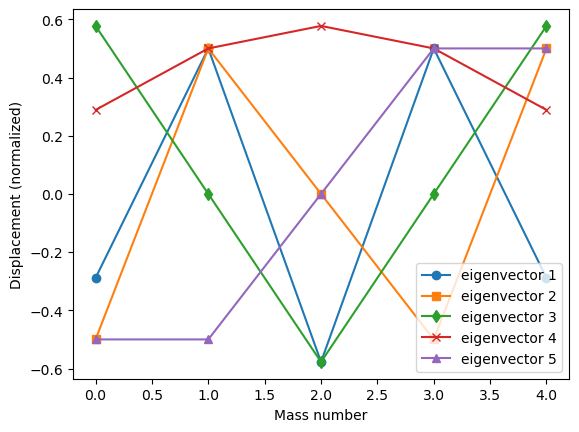

In [23]:
plot(v[:,0], 'o-', label='eigenvector 1')
plot(v[:,1], 's-', label='eigenvector 2')
plot(v[:,2], 'd-', label='eigenvector 3')
plot(v[:,3], 'x-', label='eigenvector 4')
plot(v[:,4], '^-', label='eigenvector 5')
xlabel('Mass number')
ylabel('Displacement (normalized)')
legend()
show()

# Creating Time Series Solutions

Now build up the time series for one of the masses assuming a cosine solution. Use code similar to the Intro_FFT notebook, where the amplitudes are equally weighted to each mode and the sum is over the eigenvalues
<pre>
T=5 # sec
nt = 100 # time steps
t = linspace(0,T,nt) # time array
# time series
f = A * sin(2 * pi * f1 * t) + B * sin(2 * pi * f2 * t) + C * cos(2 * pi * f3 * t) + D * cos(2 * pi * f4 * t) + E
</pre>


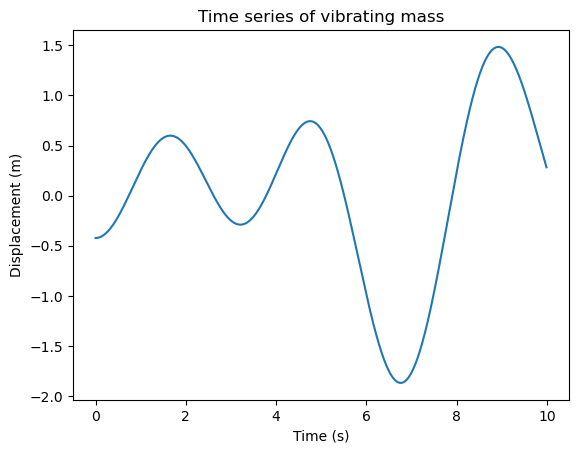

In [24]:
T=10
dt=0.01
t=arange(0,T,dt)

f = zeros(len(t)) # fill the time series with zeros to start.

# Select one mass and sum over the modes to get a time series for its motion.
imass=0

for imode in range(nx):
    A = v[imass,imode] # amplitude of the imode'th mode.
    freq = omega[imode]/(2*pi)# Get the normal frequency for the imode'th mode.
    f = f +  A*cos(2*pi*freq*t) # Add the contribution of the imode'th mode to the time series.
    
# Plot the time series for the vibrating mass.
plot(t,f)
xlabel('Time (s)')
ylabel('Displacement (m)')
title('Time series of vibrating mass')
show()

All the masses on a single graph

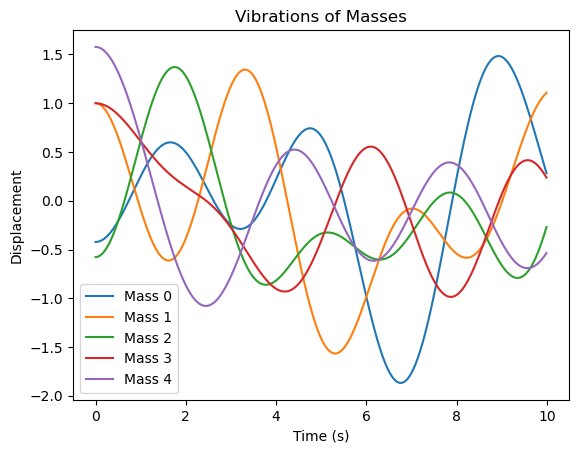

In [25]:
import matplotlib.pyplot as plt

T=10
dt=0.01
t=arange(0,T,dt)

# Create blank plot
fig, ax = plt.subplots()

# Loop over the masses
for imass in range(nx):
    f = zeros(len(t)) # reset the time series for each mass.
    # Loop over the modes to sum up the contribution of each mode to the time series for the imass'th mass.
    for imode in range(nx):
        A = v[imass,imode] # amplitude of the imode'th mode.
        freq = omega[imode]/(2*pi)# Get the normal frequency for the imode'th mode.
        f = f +  A*cos(2*pi*freq*t) # Add the contribution of the imode'th mode to the time series.
    
    # Plot the time series for the vibrating mass.

    ax.plot(t, f, label=f'Mass {imass}')
   
ax.set_xlabel('Time (s)')
ax.set_ylabel('Displacement')
ax.set_title('Vibrations of Masses')
ax.legend()
plt.show()    

# Now create a long time series and take the FFT
We need a long time series to have good resolution of the peaks. Remember that the lowest frequency is $1/T$ where $T$ is the length of the record. The frequencies are then in the sequenc $1/T, 2/T, 3/T, ...$ so the frequency resolution is $1/T$. The bigger $T$, the better the resolution. Try this with T=10 and see how the results are degraded.

The power spectrum is plotted with a maximum frequency matching the results of the eigenvalues, with the peak frequence ~0.3 Hz.

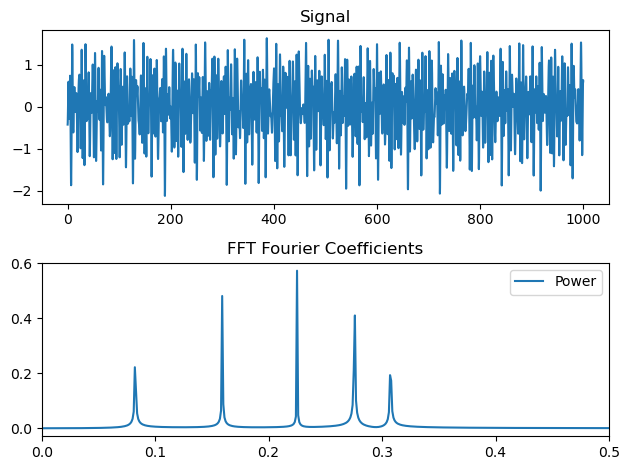

In [32]:
from scipy.fft import fft   
from numpy import real, imag, sqrt

# Select one mass and sum over the modes to get a time series for its motion.

T=1000
dt=0.1
t=arange(0,T,dt)
nt=len(t) # number of time points in the time series

freqf =  1/T # Hz   fundamental frequency (lowest frequency)
nfmax = int(nt/2) # number of frequencies resolved by FFT

freqmax = freqf*nfmax # Max frequency (Nyquist)
freq = arange(0, freqmax, freqf) # frequency array using arange(start,stop,step)

imass=0

f=zeros(len(t)) # fill the time series with zeros to start.
for imode in range(nx):
    A = v[imass,imode] # amplitude of the imode'th mode.
    f = f +  A*cos(omega[imode]*t) # Add the contribution of the imode'th mode to the time series.

# Take the FFT of the time series and plot the power spectrum to show the normal frequencies of the system.
# frequency dimension

F = fft(f)

# get the coeffs
a = 2*real(F[:nfmax])/nt # form the a coefficients
a[0] = a[0]/2

b = -2*imag(F[:nfmax])/nt # form the b coefficients

p = sqrt(a**2 + b**2) # form power spectrum

figure(1)

subplot(2,1,1)
plot(t,f)
title('Signal')

subplot(2,1,2)
# plot(freq, a, 'o', label='Cosine')
# plot(freq, b, '*', label='Sine')
plot(freq,p,'-', label='Power')
legend()

title('FFT Fourier Coefficients')
xlim(0, 0.5)
tight_layout() # prevent squished plot (matplotlib kludge)
show()

Here are the frequencies for the different modes, corresponding to the peaks in the power spectrum

In [27]:
for imode in range(nx):
    print(f"Mode {imode+1}: Frequency = {omega[imode]/2/pi:.3f} Hz")

Mode 1: Frequency = 0.307 Hz
Mode 2: Frequency = 0.276 Hz
Mode 3: Frequency = 0.225 Hz
Mode 4: Frequency = 0.082 Hz
Mode 5: Frequency = 0.159 Hz
